
# Super Tic-Tac-Toe Reinforcement Learning — Optimized Notebook

This notebook is an optimized and more complete version of the two Python files. It keeps the original idea:

1. Validate the game rules on a smaller board.
2. Add the noisy placement rule.
3. Train an RL agent on the full triangular Super Tic-Tac-Toe board.

Main improvements:
- uses a single notebook workflow for VSCode Jupyter;
- fixes the feature calculation so it is consistent with the column-cross-level rule;
- adds final evaluation against both random and heuristic opponents;
- evaluates the learner as both first and second player;
- adds random-vs-random baseline;
- saves convergence curves and final evaluation tables.


In [1]:

from __future__ import annotations

import math
import random
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Dict, List, Sequence, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Type aliases and board construction
# ============================================================

Player = int
State = Tuple[int, ...]   # 0 empty, 1 player one, -1 player two
Action = int              # zero-based cell id


@dataclass(frozen=True)
class Cell:
    id: int
    x: int
    y: int
    level: int
    block: int


@dataclass
class Board:
    cells: List[Cell]

    def __post_init__(self) -> None:
        self.coord_to_id = {(c.x, c.y): c.id for c in self.cells}

    def __len__(self) -> int:
        return len(self.cells)

    def cell(self, action: Action) -> Cell:
        return self.cells[action]

    def id_at(self, x: int, y: int) -> Optional[int]:
        return self.coord_to_id.get((x, y))

    @property
    def xs(self) -> List[int]:
        return [c.x for c in self.cells]

    @property
    def ys(self) -> List[int]:
        return [c.y for c in self.cells]


def make_rect_board(n_rows: int = 4, n_cols: int = 4) -> Board:
    """Simple rectangular board used for debugging and tabular baseline."""
    cells: List[Cell] = []
    for y in range(1, n_rows + 1):
        for x in range(1, n_cols + 1):
            cells.append(Cell(len(cells), x, y, level=1, block=1))
    return Board(cells)


def make_super_board(block_size: int = 4) -> Board:
    """
    Full assignment board: six 4x4 squares arranged as a triangle.

            level 1:      [ block 1 ]
            level 2:   [ block 1 ][ block 2 ]
            level 3: [ block 1 ][ block 2 ][ block 3 ]

    The board is embedded into a two-dimensional coordinate system.
    This makes row, column and diagonal line generation simple.
    """
    blocks = [
        # level, block, block_x, block_y
        (1, 1, 3, 1),
        (2, 1, 2, 2),
        (2, 2, 3, 2),
        (3, 1, 1, 3),
        (3, 2, 2, 3),
        (3, 3, 3, 3),
    ]

    cells: List[Cell] = []
    for level, block, block_x, block_y in blocks:
        for r in range(1, block_size + 1):
            for col in range(1, block_size + 1):
                x = (block_x - 1) * block_size + col
                y = (block_y - 1) * block_size + r
                cells.append(Cell(len(cells), x, y, level, block))
    return Board(cells)


def new_state(board: Board) -> State:
    return tuple(0 for _ in range(len(board)))


def empty_actions(state: State) -> List[Action]:
    return [i for i, value in enumerate(state) if value == 0]


def state_after_deterministic_place(state: State, action: Action, player: Player) -> State:
    state_list = list(state)
    state_list[action] = player
    return tuple(state_list)


# ============================================================
# 2. Rules: line generation, noisy placement, win checking
# ============================================================

@dataclass(frozen=True)
class Line:
    ids: Tuple[int, ...]
    kind: str


def generate_lines(board: Board, row_len: int = 4, diag_len: int = 5) -> List[Line]:
    """
    Winning rules:
    - 4 in a row
    - 4 in a column
    - 5 on a diagonal

    This function returns every legal window of the relevant length.
    """
    directions = {
        "row": (1, 0, row_len),
        "col": (0, 1, row_len),
        "diag_down": (1, 1, diag_len),
        "diag_up": (1, -1, diag_len),
    }

    seen = set()
    lines: List[Line] = []
    for cell in board.cells:
        for kind, (dx, dy, length) in directions.items():
            ids: List[int] = []
            for step in range(length):
                target = board.id_at(cell.x + dx * step, cell.y + dy * step)
                if target is None:
                    break
                ids.append(target)

            if len(ids) == length:
                key = (kind, tuple(ids))
                if key not in seen:
                    seen.add(key)
                    lines.append(Line(tuple(ids), kind))
    return lines


def line_valid_under_column_rule(board: Board, line: Line, column_must_cross_level: bool) -> bool:
    """
    Column wins are valid only if they cross at least two levels when
    column_must_cross_level=True.
    """
    if column_must_cross_level and line.kind == "col":
        levels = {board.cell(i).level for i in line.ids}
        return len(levels) >= 2
    return True


def place_mark(
    state: State,
    board: Board,
    action: Action,
    player: Player,
    noisy: bool = False,
    rng: Optional[random.Random] = None
) -> Tuple[State, bool, Optional[int]]:
    """
    Placement rule.

    If noisy=False:
        The mark is placed exactly on the chosen square.

    If noisy=True:
        1/2 probability: chosen square.
        1/16 probability each: one of the 8 neighbouring squares.
        If the sampled square is outside the board or occupied, the move is forfeited.

    Returns:
        new_state, placed_or_not, actual_target
    """
    if rng is None:
        rng = random

    if state[action] != 0:
        raise ValueError("Chosen action must be an empty square.")

    target: Optional[int] = action

    if noisy:
        u = rng.random()
        if u >= 0.5:
            cell = board.cell(action)
            neighbours = [
                (dx, dy)
                for dx in (-1, 0, 1)
                for dy in (-1, 0, 1)
                if not (dx == 0 and dy == 0)
            ]
            dx, dy = rng.choice(neighbours)
            target = board.id_at(cell.x + dx, cell.y + dy)

    if target is not None and state[target] == 0:
        state_list = list(state)
        state_list[target] = player
        return tuple(state_list), True, target

    return state, False, target


def check_win(
    state: State,
    board: Board,
    lines: Sequence[Line],
    player: Player,
    column_must_cross_level: bool = False
) -> bool:
    for line in lines:
        if not line_valid_under_column_rule(board, line, column_must_cross_level):
            continue
        if all(state[i] == player for i in line.ids):
            return True
    return False


def is_draw(state: State) -> bool:
    return all(value != 0 for value in state)


# ============================================================
# 3. Policies and game simulation
# ============================================================

Policy = Callable[[State, Board, Player, Sequence[Line]], Action]


def random_policy(state: State, board: Board, player: Player, lines: Sequence[Line]) -> Action:
    return random.choice(empty_actions(state))


def make_line_cache(board: Board, lines: Sequence[Line]) -> List[List[int]]:
    """For each action, store which winning lines contain that action."""
    by_action: List[List[int]] = [[] for _ in range(len(board))]
    for line_index, line in enumerate(lines):
        for action in line.ids:
            by_action[action].append(line_index)
    return by_action


def best_line_counts_after_action(
    state: State,
    board: Board,
    lines: Sequence[Line],
    line_cache: List[List[int]],
    action: Action,
    player: Player,
    column_must_cross_level: bool = False
) -> Tuple[int, int, bool, bool]:
    """
    Feature helper. It respects the special column-cross-level rule, so the
    feature signal is consistent with the actual win checker.
    """
    max_own_open = 0
    max_opp_open = 0
    win_now = False
    block_threat = False

    for line_index in line_cache[action]:
        line = lines[line_index]
        if not line_valid_under_column_rule(board, line, column_must_cross_level):
            continue

        values = [state[i] for i in line.ids]
        line_len = len(line.ids)
        own_before = values.count(player)
        opp_before = values.count(-player)

        # Candidate action contributes one mark for player.
        if opp_before == 0:
            own_after = own_before + 1
            max_own_open = max(max_own_open, own_after)
            if own_after == line_len:
                win_now = True

        # If the line currently contains only opponent pieces and empties,
        # placing here blocks a potential threat.
        if own_before == 0:
            max_opp_open = max(max_opp_open, opp_before)
            if opp_before >= line_len - 1:
                block_threat = True

    return max_own_open, max_opp_open, win_now, block_threat


def heuristic_policy(
    state: State,
    board: Board,
    player: Player,
    lines: Sequence[Line],
    column_must_cross_level: bool = False
) -> Action:
    """
    A stronger non-learning baseline:
    1. Win immediately if possible.
    2. Block opponent's immediate win if possible.
    3. Otherwise choose the action with best open-line and centrality score.
    """
    legal = empty_actions(state)
    line_cache = make_line_cache(board, lines)

    # Immediate win
    for a in legal:
        s2 = state_after_deterministic_place(state, a, player)
        if check_win(s2, board, lines, player, column_must_cross_level):
            return a

    # Immediate block
    for a in legal:
        s2 = state_after_deterministic_place(state, a, -player)
        if check_win(s2, board, lines, -player, column_must_cross_level):
            return a

    mean_x = sum(board.xs) / len(board.xs)
    mean_y = sum(board.ys) / len(board.ys)
    max_x = max(board.xs)
    max_y = max(board.ys)

    best_score = -1e9
    best_actions: List[int] = []

    for a in legal:
        cell = board.cell(a)
        own_open, opp_open, _, _ = best_line_counts_after_action(
            state, board, lines, line_cache, a, player, column_must_cross_level
        )
        centrality = (1.0 - abs(cell.x - mean_x) / max_x) + (1.0 - abs(cell.y - mean_y) / max_y)
        score = 1.8 * own_open + 1.2 * opp_open + 0.3 * centrality
        if score > best_score:
            best_score = score
            best_actions = [a]
        elif score == best_score:
            best_actions.append(a)

    return random.choice(best_actions)


def play_episode(
    board: Board,
    lines: Sequence[Line],
    learner_policy: Policy,
    opponent_policy: Policy = random_policy,
    noisy: bool = False,
    column_must_cross_level: bool = False,
    learner_player: Player = 1,
    rng: Optional[random.Random] = None,
    max_steps: int = 1000
) -> int:
    """
    Simulate one game.

    Returns from the learner's perspective:
        1 = learner wins
        0 = draw
       -1 = learner loses
    """
    if rng is None:
        rng = random

    state = new_state(board)
    current_player: Player = 1
    steps = 0

    while empty_actions(state) and steps < max_steps:
        steps += 1

        if current_player == learner_player:
            policy = learner_policy
        else:
            policy = opponent_policy

        action = policy(state, board, current_player, lines)
        if action not in empty_actions(state):
            action = random_policy(state, board, current_player, lines)

        state, _, _ = place_mark(state, board, action, current_player, noisy=noisy, rng=rng)

        if check_win(state, board, lines, current_player, column_must_cross_level):
            return 1 if current_player == learner_player else -1

        if is_draw(state):
            return 0

        current_player *= -1

    return 0


def evaluate_policy(
    board: Board,
    lines: Sequence[Line],
    learner_policy: Policy,
    opponent_policy: Policy = random_policy,
    n_games: int = 200,
    noisy: bool = False,
    column_must_cross_level: bool = False,
    learner_player: Player = 1,
    seed: int = 123
) -> Dict[str, float]:
    rng = random.Random(seed)
    outcomes = []
    lengths = []

    for _ in range(n_games):
        # Use play_episode for outcome.
        outcome = play_episode(
            board, lines, learner_policy, opponent_policy,
            noisy=noisy,
            column_must_cross_level=column_must_cross_level,
            learner_player=learner_player,
            rng=rng
        )
        outcomes.append(outcome)

    return {
        "win_rate": outcomes.count(1) / n_games,
        "draw_rate": outcomes.count(0) / n_games,
        "loss_rate": outcomes.count(-1) / n_games,
    }


# ============================================================
# 4. Tabular Q-learning for small boards
# ============================================================

def epsilon_greedy_tabular(
    Q: Dict[State, List[float]],
    state: State,
    epsilon: float,
    n_actions: int,
    rng: random.Random
) -> Action:
    legal = empty_actions(state)
    if rng.random() < epsilon:
        return rng.choice(legal)

    q = Q.get(state, [0.0] * n_actions)
    best_value = max(q[a] for a in legal)
    best_actions = [a for a in legal if q[a] == best_value]
    return rng.choice(best_actions)


def train_tabular_q(
    board: Board,
    lines: Sequence[Line],
    episodes: int = 1200,
    alpha: float = 0.20,
    gamma: float = 0.95,
    epsilon_start: float = 0.35,
    epsilon_end: float = 0.03,
    noisy: bool = False,
    column_must_cross_level: bool = False,
    eval_every: int = 100,
    eval_games: int = 80,
    seed: int = 7
) -> Dict[str, object]:
    rng = random.Random(seed)
    Q: Dict[State, List[float]] = {}
    n_actions = len(board)
    curve: List[Dict[str, float]] = []

    for episode in range(1, episodes + 1):
        epsilon = epsilon_end + (epsilon_start - epsilon_end) * math.exp(
            -episode / (episodes / 3)
        )

        state = new_state(board)
        done = False

        while not done and empty_actions(state):
            action = epsilon_greedy_tabular(Q, state, epsilon, n_actions, rng)
            old_state = state

            state, _, _ = place_mark(state, board, action, 1, noisy=noisy, rng=rng)

            if check_win(state, board, lines, 1, column_must_cross_level):
                reward = 1.0
                done = True
            elif is_draw(state):
                reward = 0.0
                done = True
            else:
                opp_action = random_policy(state, board, -1, lines)
                state, _, _ = place_mark(state, board, opp_action, -1, noisy=noisy, rng=rng)

                if check_win(state, board, lines, -1, column_must_cross_level):
                    reward = -1.0
                    done = True
                else:
                    reward = 0.0
                    done = is_draw(state)

            q = Q.setdefault(old_state, [0.0] * n_actions)
            target = reward
            if not done and empty_actions(state):
                next_q = Q.get(state, [0.0] * n_actions)
                target += gamma * max(next_q[a] for a in empty_actions(state))

            q[action] += alpha * (target - q[action])

        if episode % eval_every == 0:
            def greedy_policy(s: State, b: Board, p: Player, ls: Sequence[Line]) -> Action:
                return epsilon_greedy_tabular(Q, s, 0.0, len(b), rng)

            score = evaluate_policy(
                board, lines, greedy_policy,
                opponent_policy=random_policy,
                n_games=eval_games,
                noisy=noisy,
                column_must_cross_level=column_must_cross_level,
                learner_player=1,
                seed=seed + episode
            )
            curve.append({"episode": episode, **score})

    def policy(s: State, b: Board, p: Player, ls: Sequence[Line]) -> Action:
        return epsilon_greedy_tabular(Q, s, 0.0, len(b), rng)

    return {"Q": Q, "policy": policy, "curve": curve}


# ============================================================
# 5. Linear Q-learning for full board
# ============================================================

def features_for_action(
    state: State,
    board: Board,
    lines: Sequence[Line],
    line_cache: List[List[int]],
    action: Action,
    player: Player = 1,
    column_must_cross_level: bool = False
) -> List[float]:
    cell = board.cell(action)

    mean_x = sum(board.xs) / len(board.xs)
    mean_y = sum(board.ys) / len(board.ys)
    max_x = max(board.xs)
    max_y = max(board.ys)

    own_open, opp_open, win_now, block_threat = best_line_counts_after_action(
        state, board, lines, line_cache, action, player, column_must_cross_level
    )

    occupied_ratio = sum(v != 0 for v in state) / len(board)
    empty_ratio = 1.0 - occupied_ratio

    return [
        1.0,                                             # bias
        1.0 if state[action] == 0 else 0.0,              # legal/empty
        1.0 - abs(cell.x - mean_x) / max_x,              # central x
        1.0 - abs(cell.y - mean_y) / max_y,              # central y
        1.0 if cell.level == 1 else 0.0,                 # level 1
        1.0 if cell.level == 2 else 0.0,                 # level 2
        1.0 if cell.level == 3 else 0.0,                 # level 3
        own_open / 5.0,                                  # own open-line potential
        opp_open / 5.0,                                  # opponent threat level
        1.0 if win_now else 0.0,                         # immediate win
        1.0 if block_threat else 0.0,                    # immediate block
        occupied_ratio,                                  # game progress
        empty_ratio,                                     # remaining space
    ]


def dot(a: Sequence[float], b: Sequence[float]) -> float:
    return float(sum(x * y for x, y in zip(a, b)))


def q_values_linear(
    theta: Sequence[float],
    state: State,
    board: Board,
    lines: Sequence[Line],
    line_cache: List[List[int]],
    player: Player = 1,
    column_must_cross_level: bool = False
) -> Dict[Action, float]:
    return {
        action: dot(
            theta,
            features_for_action(
                state, board, lines, line_cache, action, player,
                column_must_cross_level
            )
        )
        for action in empty_actions(state)
    }


def epsilon_greedy_linear(
    theta: Sequence[float],
    state: State,
    board: Board,
    lines: Sequence[Line],
    line_cache: List[List[int]],
    epsilon: float,
    rng: random.Random,
    player: Player = 1,
    column_must_cross_level: bool = False
) -> Action:
    legal = empty_actions(state)
    if rng.random() < epsilon:
        return rng.choice(legal)

    q = q_values_linear(theta, state, board, lines, line_cache, player, column_must_cross_level)
    best_value = max(q.values())
    best_actions = [a for a, value in q.items() if value == best_value]
    return rng.choice(best_actions)


def train_linear_q(
    board: Board,
    lines: Sequence[Line],
    episodes: int = 1000,
    alpha: float = 0.035,
    gamma: float = 0.92,
    epsilon_start: float = 0.45,
    epsilon_end: float = 0.04,
    noisy: bool = True,
    column_must_cross_level: bool = True,
    eval_every: int = 100,
    eval_games: int = 60,
    seed: int = 7,
    opponent_policy: Policy = random_policy
) -> Dict[str, object]:
    rng = random.Random(seed)

    line_cache = make_line_cache(board, lines)
    n_features = len(features_for_action(new_state(board), board, lines, line_cache, 0, 1,
                                         column_must_cross_level))
    theta = [0.0] * n_features
    curve: List[Dict[str, float]] = []

    for episode in range(1, episodes + 1):
        epsilon = epsilon_end + (epsilon_start - epsilon_end) * math.exp(
            -episode / (episodes / 3)
        )

        state = new_state(board)
        done = False

        while not done and empty_actions(state):
            action = epsilon_greedy_linear(
                theta, state, board, lines, line_cache, epsilon, rng,
                player=1, column_must_cross_level=column_must_cross_level
            )
            phi = features_for_action(
                state, board, lines, line_cache, action, player=1,
                column_must_cross_level=column_must_cross_level
            )
            old_q = dot(theta, phi)

            state, placed, _ = place_mark(state, board, action, 1, noisy=noisy, rng=rng)

            if check_win(state, board, lines, 1, column_must_cross_level):
                reward = 1.0
                done = True
            elif is_draw(state):
                reward = 0.0
                done = True
            else:
                opp_action = opponent_policy(state, board, -1, lines)
                if opp_action not in empty_actions(state):
                    opp_action = random_policy(state, board, -1, lines)
                state, _, _ = place_mark(state, board, opp_action, -1, noisy=noisy, rng=rng)

                if check_win(state, board, lines, -1, column_must_cross_level):
                    reward = -1.0
                    done = True
                else:
                    # Small shaping term: encourages successful placement under noisy rule.
                    reward = 0.01 if placed else -0.02
                    done = is_draw(state)

            target = reward
            if not done and empty_actions(state):
                next_q = q_values_linear(
                    theta, state, board, lines, line_cache, player=1,
                    column_must_cross_level=column_must_cross_level
                )
                target += gamma * max(next_q.values())

            error = target - old_q
            # Clipping stabilises the linear approximation.
            theta = [
                max(-10.0, min(10.0, t + alpha * error * f))
                for t, f in zip(theta, phi)
            ]

        if episode % eval_every == 0:
            def greedy_policy(s: State, b: Board, p: Player, ls: Sequence[Line]) -> Action:
                # Use p so the same theta can be evaluated as first or second player.
                return epsilon_greedy_linear(
                    theta, s, b, ls, line_cache, 0.0, rng,
                    player=p, column_must_cross_level=column_must_cross_level
                )

            score = evaluate_policy(
                board, lines, greedy_policy,
                opponent_policy=random_policy,
                n_games=eval_games,
                noisy=noisy,
                column_must_cross_level=column_must_cross_level,
                learner_player=1,
                seed=seed + episode
            )
            curve.append({"episode": episode, **score})

    def policy(s: State, b: Board, p: Player, ls: Sequence[Line]) -> Action:
        return epsilon_greedy_linear(
            theta, s, b, ls, line_cache, 0.0, rng,
            player=p, column_must_cross_level=column_must_cross_level
        )

    return {
        "theta": theta,
        "policy": policy,
        "curve": curve,
        "line_cache": line_cache,
    }


# ============================================================
# 6. Reporting helpers
# ============================================================

def summarize_curve(curve: Sequence[Dict[str, float]], threshold: float = 0.60) -> Dict[str, object]:
    if not curve:
        return {"final_win_rate": np.nan, "best_win_rate": np.nan, "episodes_to_threshold": None}

    episodes_to_threshold = None
    for row in curve:
        if row["win_rate"] >= threshold:
            episodes_to_threshold = int(row["episode"])
            break

    return {
        "final_win_rate": curve[-1]["win_rate"],
        "best_win_rate": max(row["win_rate"] for row in curve),
        "episodes_to_threshold": episodes_to_threshold,
    }


def curve_to_dataframe(results: Dict[str, Dict[str, object]]) -> pd.DataFrame:
    rows = []
    for name, result in results.items():
        for row in result["curve"]:
            rows.append({"experiment": name, **row})
    return pd.DataFrame(rows)


def final_evaluation_table(
    experiments: Dict[str, Dict[str, object]],
    n_games: int = 500,
    seed: int = 100
) -> pd.DataFrame:
    rows = []

    for name, bundle in experiments.items():
        board = bundle["board"]
        lines = bundle["lines"]
        policy = bundle["result"]["policy"]
        noisy = bundle["noisy"]
        column_rule = bundle["column_must_cross_level"]

        for opponent_name, opponent in [
            ("random", random_policy),
            ("heuristic", lambda s, b, p, ls: heuristic_policy(s, b, p, ls, column_rule)),
        ]:
            for learner_player in [1, -1]:
                score = evaluate_policy(
                    board, lines, policy,
                    opponent_policy=opponent,
                    n_games=n_games,
                    noisy=noisy,
                    column_must_cross_level=column_rule,
                    learner_player=learner_player,
                    seed=seed + (1 if learner_player == 1 else 2)
                )
                rows.append({
                    "experiment": name,
                    "opponent": opponent_name,
                    "learner_player": "first" if learner_player == 1 else "second",
                    **score
                })

    return pd.DataFrame(rows)


def random_vs_random_baseline(
    board: Board,
    lines: Sequence[Line],
    n_games: int = 500,
    noisy: bool = True,
    column_must_cross_level: bool = True,
    seed: int = 999
) -> Dict[str, float]:
    return evaluate_policy(
        board, lines,
        learner_policy=random_policy,
        opponent_policy=random_policy,
        n_games=n_games,
        noisy=noisy,
        column_must_cross_level=column_must_cross_level,
        learner_player=1,
        seed=seed
    )


def plot_convergence(curve_df: pd.DataFrame, title: str = "RL convergence speed") -> None:
    plt.figure(figsize=(9, 5))
    for name, group in curve_df.groupby("experiment"):
        plt.plot(group["episode"], group["win_rate"], marker="o", label=name)
    plt.xlabel("Training episode")
    plt.ylabel("Evaluation win rate")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def save_outputs(curve_df: pd.DataFrame, eval_df: pd.DataFrame, out_dir: str = ".") -> None:
    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)
    curve_df.to_csv(out / "convergence_curves.csv", index=False)
    eval_df.to_csv(out / "final_evaluation_table.csv", index=False)

    plt.figure(figsize=(9, 5))
    for name, group in curve_df.groupby("experiment"):
        plt.plot(group["episode"], group["win_rate"], marker="o", label=name)
    plt.xlabel("Training episode")
    plt.ylabel("Evaluation win rate")
    plt.title("RL convergence speed")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out / "convergence_curves.png", dpi=200)
    plt.show()


# ============================================================
# 7. Sanity checks
# ============================================================

def run_sanity_checks() -> None:
    board = make_super_board(4)
    assert len(board) == 96
    assert sum(c.level == 1 for c in board.cells) == 16
    assert sum(c.level == 2 for c in board.cells) == 32
    assert sum(c.level == 3 for c in board.cells) == 48

    state = new_state(board)
    state2, placed, target = place_mark(state, board, 0, 1, noisy=False)
    assert placed and target == 0 and state2[0] == 1

    lines = generate_lines(board, row_len=4, diag_len=5)

    # Same-level column should not win when column_must_cross_level=True.
    same_level_ids = tuple(board.id_at(9, y) for y in range(1, 5))
    cross_level_ids = tuple(board.id_at(9, y) for y in range(4, 8))
    assert all(i is not None for i in same_level_ids)
    assert all(i is not None for i in cross_level_ids)

    same_level_state = tuple(1 if i in same_level_ids else 0 for i in range(len(board)))
    cross_level_state = tuple(1 if i in cross_level_ids else 0 for i in range(len(board)))

    assert check_win(same_level_state, board, lines, 1, column_must_cross_level=False)
    assert not check_win(same_level_state, board, lines, 1, column_must_cross_level=True)
    assert check_win(cross_level_state, board, lines, 1, column_must_cross_level=True)

    print("All sanity checks passed.")


# ============================================================
# 8. Main experiment runner
# ============================================================

def run_all_experiments(
    run_small_tabular: bool = True,
    full_episodes: int = 1000,
    final_eval_games: int = 500,
    output_dir: str = "super_tictactoe_outputs"
) -> Tuple[Dict[str, Dict[str, object]], pd.DataFrame, pd.DataFrame]:
    random.seed(7)

    experiments: Dict[str, Dict[str, object]] = {}

    if run_small_tabular:
        print("Step 1: deterministic 4x4 board with tabular Q-learning")
        base_board = make_rect_board(4, 4)
        base_lines = generate_lines(base_board, row_len=4, diag_len=4)
        t0 = time.time()
        base_det = train_tabular_q(
            base_board, base_lines,
            episodes=1200,
            noisy=False,
            eval_every=100,
            eval_games=80,
            seed=7
        )
        print(f"  Finished in {time.time() - t0:.2f}s")

        experiments["base_deterministic_tabular"] = {
            "board": base_board,
            "lines": base_lines,
            "result": base_det,
            "noisy": False,
            "column_must_cross_level": False,
        }

        print("Step 2: noisy 4x4 board with tabular Q-learning")
        t0 = time.time()
        base_noisy = train_tabular_q(
            base_board, base_lines,
            episodes=1600,
            noisy=True,
            eval_every=100,
            eval_games=80,
            seed=11
        )
        print(f"  Finished in {time.time() - t0:.2f}s")

        experiments["base_noisy_tabular"] = {
            "board": base_board,
            "lines": base_lines,
            "result": base_noisy,
            "noisy": True,
            "column_must_cross_level": False,
        }

    print("Step 3: full triangular super board with linear Q-learning")
    super_board = make_super_board(4)
    super_lines = generate_lines(super_board, row_len=4, diag_len=5)

    t0 = time.time()
    full_linear = train_linear_q(
        super_board, super_lines,
        episodes=full_episodes,
        noisy=True,
        column_must_cross_level=True,
        eval_every=max(100, full_episodes // 10),
        eval_games=60,
        seed=19,
        opponent_policy=random_policy
    )
    print(f"  Finished in {time.time() - t0:.2f}s")

    experiments["full_super_linear"] = {
        "board": super_board,
        "lines": super_lines,
        "result": full_linear,
        "noisy": True,
        "column_must_cross_level": True,
    }

    curve_df = curve_to_dataframe({name: bundle["result"] for name, bundle in experiments.items()})
    eval_df = final_evaluation_table(experiments, n_games=final_eval_games)

    # Add random-vs-random baseline for the full board.
    rv = random_vs_random_baseline(
        super_board, super_lines,
        n_games=final_eval_games,
        noisy=True,
        column_must_cross_level=True
    )
    baseline_row = {
        "experiment": "full_super_random_vs_random",
        "opponent": "random",
        "learner_player": "first",
        **rv
    }
    eval_df = pd.concat([eval_df, pd.DataFrame([baseline_row])], ignore_index=True)

    save_outputs(curve_df, eval_df, out_dir=output_dir)

    return experiments, curve_df, eval_df



## 1. Run sanity checks

These checks verify board size, noisy/deterministic placement, and the special column-cross-level rule.


In [2]:
run_sanity_checks()

All sanity checks passed.



## 2. Run experiments

Default setting:
- small 4x4 tabular baselines are included;
- full board uses linear Q-learning;
- final evaluation uses 500 games.

If it runs too slowly, reduce `full_episodes` to 500 and `final_eval_games` to 200 first.


Step 1: deterministic 4x4 board with tabular Q-learning
  Finished in 1.82s
Step 2: noisy 4x4 board with tabular Q-learning
  Finished in 3.97s
Step 3: full triangular super board with linear Q-learning
  Finished in 238.47s


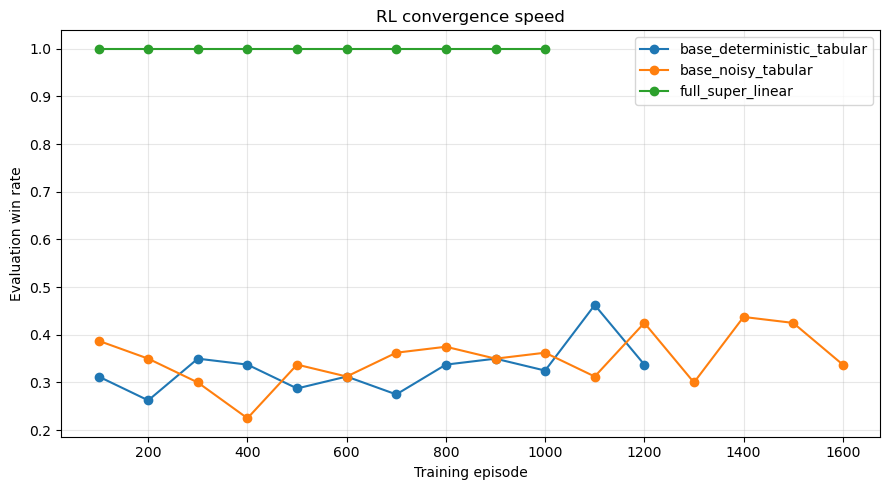

In [3]:

experiments, curve_df, eval_df = run_all_experiments(
    run_small_tabular=True,
    full_episodes=1000,
    final_eval_games=500,
    output_dir="super_tictactoe_outputs"
)


## 3. Convergence curve data

In [4]:
curve_df

,experiment,episode,win_rate,draw_rate,loss_rate
0,base_deterministic_tabular,100,0.3125,0.4000,0.2875
1,base_deterministic_tabular,200,0.2625,0.5000,0.2375
2,base_deterministic_tabular,300,0.3500,0.3875,0.2625
3,base_deterministic_tabular,400,0.3375,0.4125,0.2500
4,base_deterministic_tabular,500,0.2875,0.4625,0.2500
5,base_deterministic_tabular,600,0.3125,0.4625,0.2250
6,base_deterministic_tabular,700,0.2750,0.4125,0.3125
7,base_deterministic_tabular,800,0.3375,0.4000,0.2625
8,base_deterministic_tabular,900,0.3500,0.3375,0.3125
9,base_deterministic_tabular,1000,0.3250,0.4375,0.2375


## 4. Final evaluation table

In [5]:
eval_df

,experiment,opponent,learner_player,win_rate,draw_rate,loss_rate
0,base_deterministic_tabular,random,first,0.348,0.392,0.260
1,base_deterministic_tabular,random,second,0.246,0.406,0.348
2,base_deterministic_tabular,heuristic,first,0.000,0.088,0.912
3,base_deterministic_tabular,heuristic,second,0.000,0.028,0.972
4,base_noisy_tabular,random,first,0.392,0.318,0.290
5,base_noisy_tabular,random,second,0.310,0.322,0.368
6,base_noisy_tabular,heuristic,first,0.070,0.148,0.782
7,base_noisy_tabular,heuristic,second,0.034,0.132,0.834
8,full_super_linear,random,first,1.000,0.000,0.000
9,full_super_linear,random,second,0.996,0.000,0.004


## 5. Summary table

In [6]:

summary_rows = []
for name, bundle in experiments.items():
    s = summarize_curve(bundle["result"]["curve"], threshold=0.60)
    summary_rows.append({"experiment": name, **s})
summary_df = pd.DataFrame(summary_rows)
summary_df


,experiment,final_win_rate,best_win_rate,episodes_to_threshold
0,base_deterministic_tabular,0.3375,0.4625,NaN
1,base_noisy_tabular,0.3375,0.4375,NaN
2,full_super_linear,1.0000,1.0000,100.0


## 6. Plot convergence curves

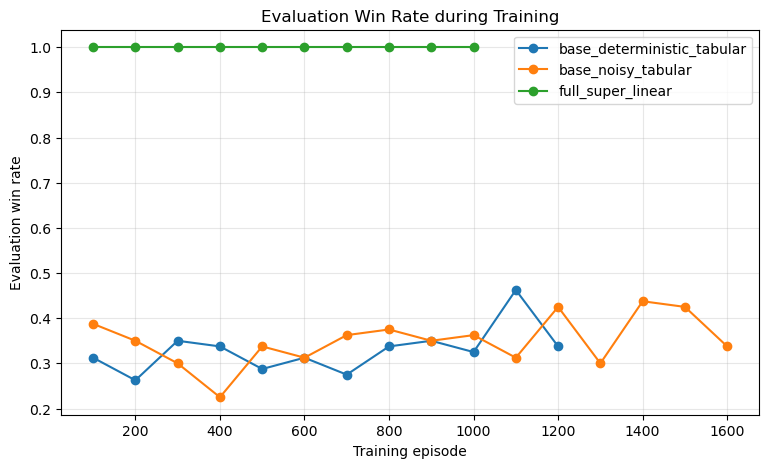

In [7]:
plot_convergence(curve_df, title='Evaluation Win Rate during Training')


## 7. Optional: inspect learned linear weights

The full-board agent uses a linear approximation:
\[
Q(s,a) \approx \theta^\top \phi(s,a).
\]
This cell shows the learned feature weights.


In [8]:

theta = experiments["full_super_linear"]["result"]["theta"]
feature_names = [
    "bias", "is_empty", "central_x", "central_y",
    "level_1", "level_2", "level_3",
    "own_open", "opp_open", "win_now", "block_threat",
    "occupied_ratio", "empty_ratio"
]
pd.DataFrame({"feature": feature_names, "theta": theta})


,feature,theta
0,bias,0.262898
1,is_empty,0.262898
2,central_x,-0.005894
3,central_y,-0.009353
4,level_1,0.085918
5,level_2,0.075169
6,level_3,0.101811
7,own_open,0.225287
8,opp_open,0.034118
9,win_now,0.112692



## 8. How to use the outputs in the report

The notebook saves three output files under `super_tictactoe_outputs/`:

- `convergence_curves.csv`
- `final_evaluation_table.csv`
- `convergence_curves.png`

Recommended report discussion:
1. Explain the board encoding and noisy placement.
2. Explain RL formulation: state, action, transition, reward.
3. Explain why tabular Q-learning is feasible only for small boards.
4. Explain why linear Q-learning is used for the full 96-cell board.
5. Use `curve_df` and `eval_df` to discuss convergence and final performance.
